Running 100 SIS simulations with immunization:
	Infection rate: 0.3
	Recovery rate: 0.6
	Immunity strategy: ImmunisationStrategy.RANDOM
	Values of g: 20


Progress ImmunisationStrategy.RANDOM strategy: 100%|██████████| 20/20 [14:03<00:00, 42.17s/it]


Running 100 SIS simulations with immunization:
	Infection rate: 0.3
	Recovery rate: 0.6
	Immunity strategy: ImmunisationStrategy.TARGETED
	Values of g: 20


Progress ImmunisationStrategy.TARGETED strategy: 100%|██████████| 20/20 [12:29<00:00, 37.46s/it]


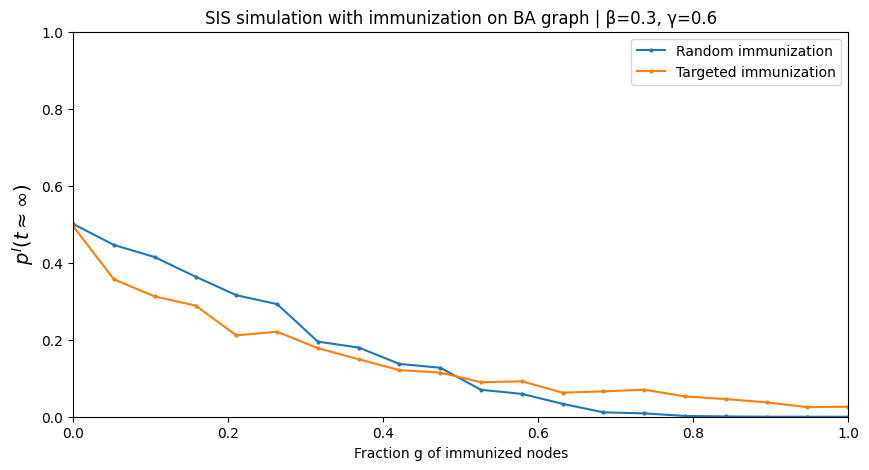

In [5]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from enum import Enum, auto
from tqdm import tqdm
from statistics import mean
from typing import Iterable, List, Tuple, Set

class ImmunisationStrategy(Enum):
    RANDOM = auto()
    TARGETED = auto()

def largest_node_neighbor(graph: nx.Graph, node: str) -> str:
    try:
        return max(
            graph.neighbors(node),
            key=lambda node: graph.degree(node)
        )
    except:
        return None

def sis_run_with_immune(
    network: nx.Graph,
    infection_rate: float,
    recovery_rate: float,
    infected_seed_node: str,
    immune_nodes: Set[str],
    time_steps=1000
) -> float:
    infected = {infected_seed_node}
    probs_infected = []

    for _ in range(time_steps):
        for infected_node in infected.copy():
            if np.random.rand() < recovery_rate:
                infected.remove(infected_node)

            non_immune_neighbors = set(network.neighbors(infected_node)).difference(immune_nodes)

            for neighbor in non_immune_neighbors.difference(infected):
                if np.random.rand() < infection_rate:
                    infected.add(neighbor)

        prob_infected = len(infected) / len(network.nodes())
        probs_infected.append(prob_infected)

    return mean(probs_infected) if len(probs_infected) > 0 else 0

def get_immune_nodes(
    graph: nx.Graph,
    fraction: float,
    strategy: ImmunisationStrategy,
) -> Set[str]:
    graph_nodes = list(graph.nodes())
    np.random.shuffle(graph_nodes)
    num_node_selection = int(fraction * len(graph.nodes()))
    immune_nodes = set()

    for node in graph_nodes[:num_node_selection]:
        if strategy == ImmunisationStrategy.RANDOM:
            immune_nodes.add(node)
            continue

        largest_neighbor = largest_node_neighbor(graph, node)
        if largest_neighbor is not None:
            immune_nodes.add(largest_neighbor)

    return immune_nodes

def sis_samples_with_immune(
    graph: nx.Graph,
    infection_rate: float,
    recovery_rate: float,
    immunity_fractions: List[float],
    immunity_strategy: ImmunisationStrategy,
):
    probs_infected = []
    num_sis_simulation = 100
    num_sis_time_steps = 1000

    print(f"Running {num_sis_simulation} SIS simulations with immunization:")
    print(f"\tInfection rate: {infection_rate}")
    print(f"\tRecovery rate: {recovery_rate}")
    print(f"\tImmunity strategy: {immunity_strategy}")
    print(f"\tValues of g: {len(immunity_fractions)}")

    for g in tqdm(immunity_fractions, desc=f"Progress {immunity_strategy} strategy: "):
        probs_avg = []
        for _ in range(num_sis_simulation):
            infected_seed_node = np.random.choice(list(graph.nodes()))
            immune_nodes = get_immune_nodes(graph, g, immunity_strategy)
            prob_infected = sis_run_with_immune(
                network=graph,
                infection_rate=infection_rate,
                recovery_rate=recovery_rate,
                immune_nodes=immune_nodes,
                infected_seed_node=infected_seed_node,
                time_steps=num_sis_time_steps,
            )
            probs_avg.append(prob_infected)
        probs_infected.append(mean(probs_avg))

    return probs_infected, num_sis_simulation, num_sis_time_steps

def ba_sis_immunization():
    graph = nx.barabasi_albert_graph(n=1000, m=3)
    num_g_values = 20
    g = list(np.linspace(0, 1, num_g_values))
    beta = 0.3
    gamma = 0.6
    (
        sis_immunity_random,
        num_sis_simulations,
        num_sis_time_steps,
    ) = sis_samples_with_immune(
        graph,
        infection_rate=beta,
        recovery_rate=gamma,
        immunity_fractions=g,
        immunity_strategy=ImmunisationStrategy.RANDOM,
    )

    sis_immunity_targeted, _, _ = sis_samples_with_immune(
        graph,
        infection_rate=beta,
        recovery_rate=gamma,
        immunity_fractions=g,
        immunity_strategy=ImmunisationStrategy.TARGETED,
    )
    return (
        sis_immunity_random,
        sis_immunity_targeted,
        g,
        graph,
        num_sis_simulations,
        num_sis_time_steps,
    )

def plot_t1_4():
    (
        sis_immunity_random,
        sis_immunity_targeted,
        g,
        _,
        num_sis_simulations,
        num_sis_time_steps,
    ) = ba_sis_immunization()

    fig, ax = plt.subplots(1, 1, figsize=(10, 5))

    ax.set_title(f"SIS simulation with immunization on BA graph | β=0.3, γ=0.6")
    ax.set_xlabel("Fraction g of immunized nodes")
    ax.set_ylabel(r"$p^I(t\approx\infty)$", fontsize=14)
    ax.set_ylim(0, 1)
    ax.set_xlim(0, 1)

    ax.plot(
        g,
        sis_immunity_random,
        label="Random immunization",
        marker="o",
        ms=2,
    )
    ax.plot(
        g,
        sis_immunity_targeted,
        label="Targeted immunization",
        marker="o",
        ms=2,
    )
    ax.legend()

plot_t1_4()
plt.show()
